## Notebook to illustrate how to use and connect tiled server to sidpy
- Tiled includes a Python client for reading and writing data, with strong integration with libraries like numpy, pandas, and dask. 
- Tiled is secure
- it supports N-dimensional array data, tabular data, and nested directory-like containers of these. 
- Tiled supports parallel uploads and downloads for efficient transfers.
- Q's
    - Q1. Does it make data searchable(without downloading)? - yes
    - Q2. Does it make data plottable(without downloading)? - yes
    - Q3. Say I have bunch of hdf5 files in a folder - tiled server can see that folder - can I query it thourgh the client or specific dataformaating needed? 
        ```python
            #     GPT says:
            from tiled.client import from_uri

            c = from_uri("http://localhost:8000")
            list(c)          # files / top-level nodes
            node = c["myfile.h5"]
            list(node)       # groups/datasets inside the HDF5 file
            arr = node["group"]["dataset"]
            data = arr.read()
        ```
    - Q3. The data can sit on a separate computer? - yes as the server
    - Q4. client is my laptop? - yes
    - Q5. Can offload sidpy dataset somewhere else - load it back? -- need to check

NOTE: MAC-OS issue in running the server 
- TimeoutError: Server did not start in 20 seconds.

In [1]:
from tiled.client import from_uri

c = from_uri("https://tiled-demo.nsls2.bnl.gov")

In [2]:
c

<Container {'bmm', 'csx', 'fxi', 'examples'}>

In [3]:
c['examples']


<Container {'images', 'xraydb'}>

In [4]:
c['examples/xraydb']


<Container {'H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', ...} ~98 entries>

In [5]:
c['examples/xraydb'].metadata


{'description': 'X-ray reference data for the elements, sourced from XrayDB '
                '(https://github.com/xraypy/XrayDB). Includes mass attenuation '
                'coefficients, emission lines, and absorption edges.',
 'energy_units': 'eV',
 'mu_units': 'cm^2/g',
 'source': 'xraydb',
 'version': '9.2'}

In [6]:
x = c['examples/xraydb']
x.values().first().metadata

{'edges': {'K': {'energy_eV': 13.6,
                 'fluorescence_yield': 0.0,
                 'jump_ratio': 1.0}},
 'element': {'atomic_number': 1,
             'category': 'nonmetal',
             'density_g_cm3': 0.0001,
             'molar_mass': 1.0078,
             'name': 'hydrogen',
             'period': 1,
             'symbol': 'H'}}

In [7]:
from tiled.queries import Key

x.search(Key('element.category') == 'nonmetal')

<Container {'H', 'C', 'N', 'O', 'P', 'S', 'Se'}>

In [8]:
x.search(
    Key('element.category') == 'nonmetal'
).search(
    Key('element.atomic_number') < 16
)

<Container {'H', 'C', 'N', 'O', 'P'}>

In [9]:
x.distinct('element.category', counts=True)['metadata']


{'element.category': [{'value': None, 'count': 0},
  {'value': 'alkaline_earth', 'count': 6},
  {'value': 'alkali_metal', 'count': 6},
  {'value': 'post_transition_metal', 'count': 8},
  {'value': 'transition_metal', 'count': 29},
  {'value': 'actinide', 'count': 10},
  {'value': 'nonmetal', 'count': 7},
  {'value': 'metalloid', 'count': 6},
  {'value': 'halogen', 'count': 5},
  {'value': 'lanthanide', 'count': 15},
  {'value': 'noble_gas', 'count': 6}]}

In [10]:
results = x.search(Key('element.category') == 'noble_gas')
print(f"Noble gases in this data set: {list(results)}")

Noble gases in this data set: ['He', 'Ne', 'Ar', 'Kr', 'Xe', 'Rn']


In [11]:
first_result = results.values().first()
first_result.metadata

{'edges': {'K': {'energy_eV': 24.6,
                 'fluorescence_yield': 0.0,
                 'jump_ratio': 1.0}},
 'element': {'atomic_number': 2,
             'category': 'noble_gas',
             'density_g_cm3': 0.0002,
             'molar_mass': 4.0026,
             'name': 'helium',
             'period': 1,
             'symbol': 'He'}}

In [12]:
c['examples/xraydb/C/edges']


<DataFrameClient ['edge', 'energy_eV', 'fluorescence_yield', 'jump_ratio']>

In [13]:
c['examples/xraydb/C/edges'].read()


,edge,energy_eV,fluorescence_yield,jump_ratio
0,K,284.2,0.0014,19.02
1,L1,18.0,0.0000,1.00
2,L2,7.2,0.0000,1.00
3,L3,7.2,0.0000,1.00


In [14]:
c['examples/images/binary_blobs']


<ArrayClient shape=(512, 512) chunks=((512,), (512,)) dtype=bool>

In [15]:
arr = c['examples/images/binary_blobs'].read()


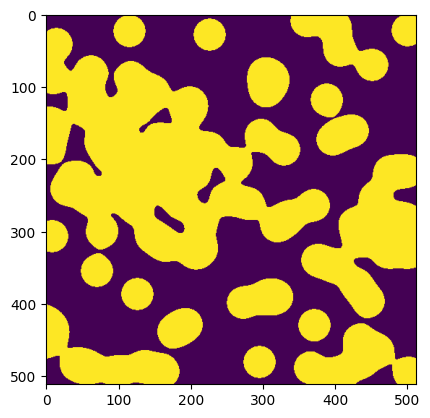

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(arr)